<a href="https://colab.research.google.com/github/hykim-1/Study/blob/main/LSTM_smartphone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import numpy as np, pandas as pd
from keras.utils import to_categorical
import matplotlib.pyplot as plt, seaborn as sns
import keras
from keras import layers
import tensorflow as tf
from sklearn.metrics import f1_score, classification_report, accuracy_score, confusion_matrix, precision_recall_fscore_support

SEED=42
np.random.seed(SEED); tf.random.set_seed(SEED)


In [2]:
def load_file(filepath):
    dataframe = pd.read_csv(filepath, header=None, delim_whitespace=True)
    return dataframe.values

def load_group(filenames, prefix=''):
    loaded=[]
    for name in filenames:
        loaded.append(load_file(prefix + name))
    return np.dstack(loaded)

def load_dataset_group(group, prefix=''):
    filepath = prefix + group + '/Inertial Signals/'
    filenames=[]
    filenames += [f'total_acc_{ax}_{group}.txt' for ax in ['x','y','z']]
    filenames += [f'body_acc_{ax}_{group}.txt'  for ax in ['x','y','z']]
    filenames += [f'body_gyro_{ax}_{group}.txt' for ax in ['x','y','z']]
    X = load_group(filenames, filepath)
    y = load_file(prefix + group + f'/y_{group}.txt')
    return X, y

def load_dataset(prefix=''):
    base = '/content/drive/MyDrive/Colab Notebooks/UCI HAR Dataset/UCI HAR Dataset/'
    trainX, trainy = load_dataset_group('train', base)
    testX,  testy  = load_dataset_group('test',  base)
    trainy = trainy - 1; testy = testy - 1
    print("Shapes:", "trainX",trainX.shape,"trainy",trainy.shape,"| testX",testX.shape,"testy",testy.shape)
    return trainX, trainy, testX, testy

X_train, y_train, X_test, y_test = load_dataset()
num_classes = len(np.unique(y_train))
y_train_oh = to_categorical(y_train); y_test_oh = to_categorical(y_test)

timesteps, n_channels = X_train.shape[1], X_train.shape[2]
input_shape = (timesteps, n_channels)

/tmp/ipython-input-558060647.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dataframe = pd.read_csv(filepath, header=None, delim_whitespace=True)
/tmp/ipython-input-558060647.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dataframe = pd.read_csv(filepath, header=None, delim_whitespace=True)
/tmp/ipython-input-558060647.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dataframe = pd.read_csv(filepath, header=None, delim_whitespace=True)
/tmp/ipython-input-558060647.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dataframe = pd.read_csv(filepath, header=None, delim_whitespace=True)
/tmp

Shapes: trainX (7352, 128, 9) trainy (7352, 1) | testX (2947, 128, 9) testy (2947, 1)


In [3]:
# ----- Model -----
def build_lstm(input_shape, num_classes):
    inp = keras.Input(shape=input_shape)
    x = layers.LSTM(128, return_sequences=True)(inp)
    x = layers.Dropout(0.3)(x)
    x = layers.LSTM(64)(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inp, out, name="LSTM")

model = build_lstm(input_shape, num_classes)
model.summary()


Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 9)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128, 128)       │        70,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 120,454 (470.52 KB)

 Trainable params: 120,454 (470.52 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# ----- Train -----
opt = keras.optimizers.Adam(1e-3)
model.compile(optimizer=opt, loss="categorical_crossentropy", metrics=["accuracy"])
callbacks=[keras.callbacks.EarlyStopping(monitor="loss", patience=3, restore_best_weights=True)]
history = model.fit(X_train, y_train_oh, epochs=30, batch_size=64, verbose=2, callbacks=callbacks)

Epoch 1/30
115/115 - 7s - 59ms/step - accuracy: 0.5681 - loss: 1.0337
Epoch 2/30
115/115 - 1s - 12ms/step - accuracy: 0.7583 - loss: 0.6316
Epoch 3/30
115/115 - 2s - 15ms/step - accuracy: 0.8273 - loss: 0.4653
Epoch 4/30
115/115 - 1s - 12ms/step - accuracy: 0.8968 - loss: 0.3165
Epoch 5/30
115/115 - 2s - 16ms/step - accuracy: 0.9180 - loss: 0.2412
Epoch 6/30
115/115 - 2s - 16ms/step - accuracy: 0.9366 - loss: 0.1796
Epoch 7/30
115/115 - 1s - 13ms/step - accuracy: 0.9105 - loss: 0.2600
Epoch 8/30
115/115 - 2s - 16ms/step - accuracy: 0.9348 - loss: 0.1854
Epoch 9/30
115/115 - 2s - 14ms/step - accuracy: 0.9369 - loss: 0.1645
Epoch 10/30
115/115 - 2s - 20ms/step - accuracy: 0.9374 - loss: 0.1641
Epoch 11/30
115/115 - 1s - 12ms/step - accuracy: 0.9403 - loss: 0.1632
Epoch 12/30
115/115 - 1s - 12ms/step - accuracy: 0.9471 - loss: 0.1325
Epoch 13/30
115/115 - 4s - 35ms/step - accuracy: 0.9408 - loss: 0.1785
Epoch 14/30
115/115 - 1s - 12ms/step - accuracy: 0.9387 - loss: 0.1670
Epoch 15/30
115

In [5]:
# ----- Test & Print -----
probs = model.predict(X_test, verbose=0)
y_pred = probs.argmax(axis=1); y_true = y_test.flatten()
acc = accuracy_score(y_true, y_pred); f1m = f1_score(y_true, y_pred, average="macro")
print(f"[TEST] Acc={acc:.4f} | Macro-F1={f1m:.4f}")
print("\n[TEST] Classification Report"); print(classification_report(y_true, y_pred, digits=4))


[TEST] Acc=0.9118 | Macro-F1=0.9136

[TEST] Classification Report
              precision    recall  f1-score   support

           0     0.9705    0.9274    0.9485       496
           1     0.9060    0.9618    0.9331       471
           2     0.9633    1.0000    0.9813       420
           3     0.7965    0.8289    0.8124       491
           4     0.8469    0.8008    0.8232       532
           5     0.9962    0.9702    0.9830       537

    accuracy                         0.9118      2947
   macro avg     0.9132    0.9148    0.9136      2947
weighted avg     0.9125    0.9118    0.9117      2947



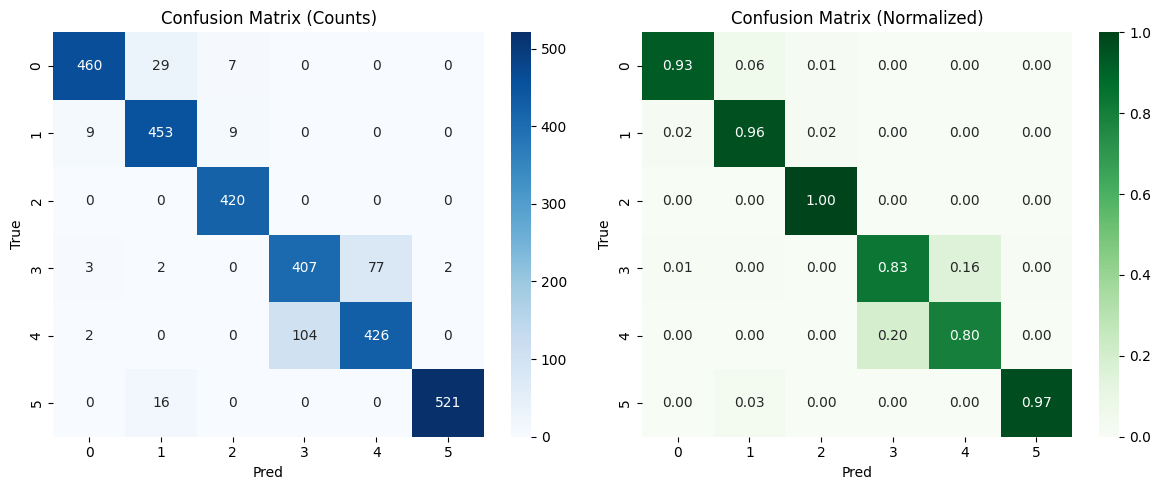

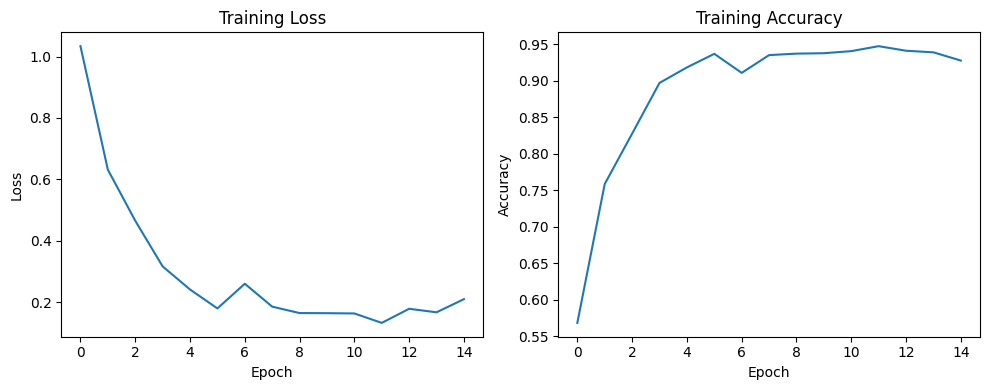

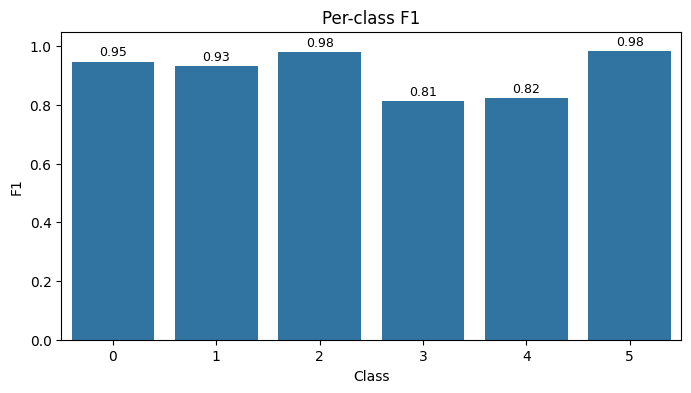


TF: 2.19.0 | Keras: 3.10.0 | Backend: tensorflow


In [6]:
# ----- Plots -----
cm = confusion_matrix(y_true, y_pred); cm_norm = confusion_matrix(y_true, y_pred, normalize='true')
plt.figure(figsize=(12,5))
plt.subplot(1,2,1); sns.heatmap(cm, annot=True, fmt='d', cmap='Blues'); plt.title('Confusion Matrix (Counts)'); plt.xlabel('Pred'); plt.ylabel('True')
plt.subplot(1,2,2); sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens'); plt.title('Confusion Matrix (Normalized)'); plt.xlabel('Pred'); plt.ylabel('True')
plt.tight_layout(); plt.show()

hist = history.history
plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.plot(hist.get('loss', [])); plt.title('Training Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.subplot(1,2,2); plt.plot(hist.get('accuracy', [])); plt.title('Training Accuracy'); plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.tight_layout(); plt.show()

prec, rec, f1s, support = precision_recall_fscore_support(y_true, y_pred, zero_division=0)
classes = np.arange(len(f1s))
plt.figure(figsize=(8,4)); sns.barplot(x=classes, y=f1s); plt.title('Per-class F1'); plt.xlabel('Class'); plt.ylabel('F1')
for i, v in enumerate(f1s): plt.text(i, v+0.01, f"{v:.2f}", ha='center', va='bottom', fontsize=9)
plt.ylim(0,1.05); plt.show()

print("\nTF:", tf.__version__, "| Keras:", keras.__version__, "| Backend:", keras.backend.backend())